# Gaming Industry Performance Analysis : Revenue, Palyers and Market trends

# Which games generate the highest revenue per player, and what patterns do they share (genre, platform, developer)?
# Which platform (Xbox, Mobile, PC, etc.) has the highest average revenue and player base?
# Which game genres are most associated with a “Rising” trending status versus “Declining”?
# Do games with esports popularity (“Yes”) have higher average players or revenue than those without?
# Is there a relationship between release year and game success (revenue, players, or trending status)?
# Which developers consistently produce high-performing games based on revenue and player metrics?

In [ ]:
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "/Users/love/Desktop/Project Data Analyst /TEPP/data/processed/gaming_industry_trends.csv"
df = pd.read_csv(csv_path)

df.head()

,Game Title,Genre,Platform,Release Year,Developer,Revenue (Millions $),Players (Millions),Peak Concurrent Players,Metacritic Score,Esports Popularity,Trending Status
0,Neon Speed 5,Strategy,Xbox,2011,Capcom,52.28,77.99,21.44,69,No,Stable
1,Cyber Quest 5,Shooter,Mobile,2018,Bandai Namco,4345.97,65.28,11.22,72,No,Stable
2,Fantasy Rivals 1,Strategy,Xbox,2018,Microsoft,1278.29,160.09,48.40,51,Yes,Declining
3,Warzone Chronicles 5,Horror,Xbox,2002,Microsoft,361.26,98.14,32.96,91,No,Declining
4,Cyber Quest 4,RPG,PC,2018,EA,4549.27,199.47,58.39,74,No,Stable


In [12]:
df["revenue_per_player"] = df["revenue_millions_"] / df["players_millions"]

top_efficiency = df[["game_title", "genre", "platform", "developer", "revenue_per_player"]] \
    .sort_values(by="revenue_per_player", ascending=False) \
    .head(10)

top_efficiency

,game_title,genre,platform,developer,revenue_per_player
493,Neon Speed 2,Simulation,PlayStation,Nintendo,5581.018868
12,Zombie Outbreak 4,Fighting,Mobile,Activision,5436.186441
125,Neon Speed 3,Fighting,Nintendo Switch,Ubisoft,4481.419048
974,Zombie Outbreak 1,Fighting,Cross-Platform,Nintendo,4298.638095
434,Cyber Quest 4,Shooter,Nintendo Switch,Activision,3848.263158
815,Pixel Odyssey 2,Adventure,Nintendo Switch,Rockstar,2679.666667
603,Neon Speed 1,Adventure,PC,Sony,2232.105023
348,Warzone Chronicles 2,Sports,Mobile,Nintendo,1499.704641
641,Fantasy Rivals 4,Action,Xbox,EA,1324.332226
227,Neon Speed 1,RPG,PlayStation,Microsoft,1286.341463


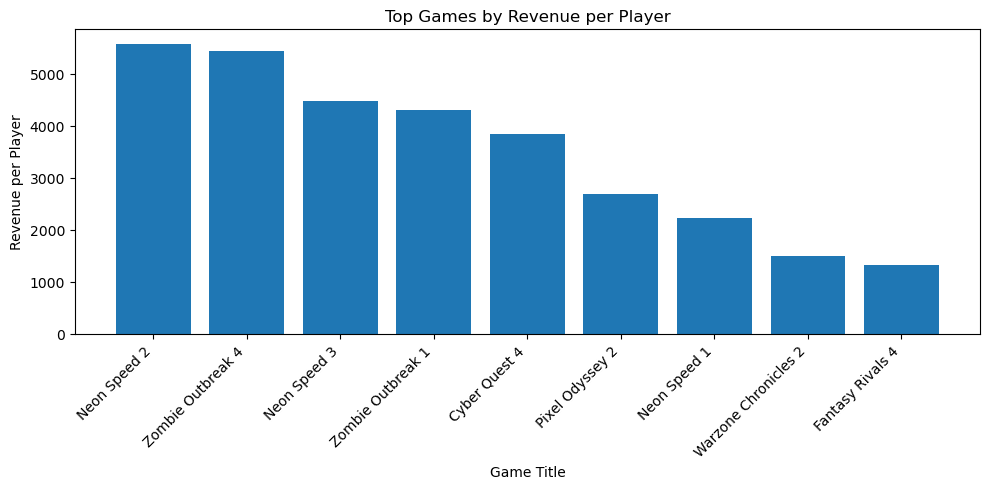

In [11]:
plt.figure(figsize=(10, 5))
plt.bar(top_efficiency["game_title"], top_efficiency["revenue_per_player"])
plt.xticks(rotation=45, ha="right")
plt.title("Top Games by Revenue per Player")
plt.xlabel("Game Title")
plt.ylabel("Revenue per Player")
plt.tight_layout()
plt.show()

In [13]:
platform_perf = df.groupby("platform")[["revenue_millions_", "players_millions"]] \
    .mean() \
    .sort_values(by="revenue_millions_", ascending=False)

platform_perf

,revenue_millions_,players_millions
platform,,
Nintendo Switch,2576.591456,95.087532
Mobile,2525.948734,98.654304
Cross-Platform,2521.600536,108.085298
Xbox,2462.605808,106.826766
PC,2450.061782,106.214885
PlayStation,2374.980800,105.193257


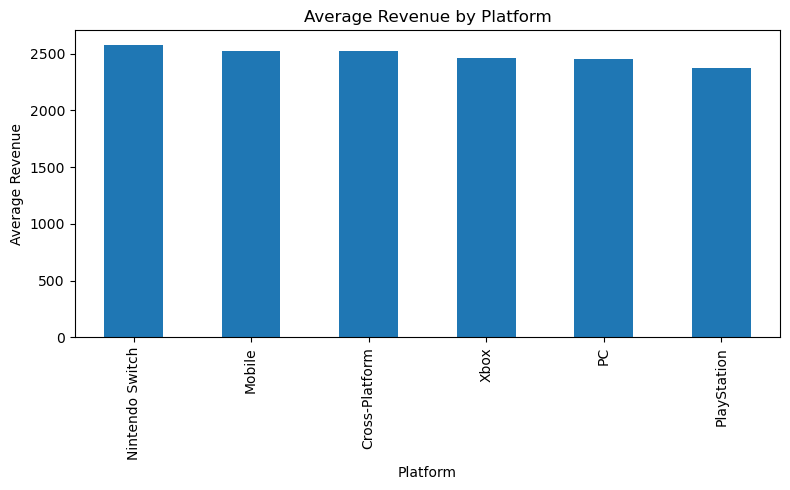

In [14]:
platform_perf["revenue_millions_"].plot(kind="bar", figsize=(8, 5))
plt.title("Average Revenue by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Revenue")
plt.tight_layout()
plt.show()

In [15]:
genre_trends = df.groupby(["genre", "trending_status"]).size().unstack(fill_value=0)

genre_trends

trending_status,Declining,Rising,Stable
genre,,,
Action,35,46,41
Adventure,32,29,26
Fighting,33,41,29
Horror,26,32,38
RPG,29,22,27
Racing,30,33,32
Shooter,32,34,34
Simulation,33,24,30
Sports,30,40,46


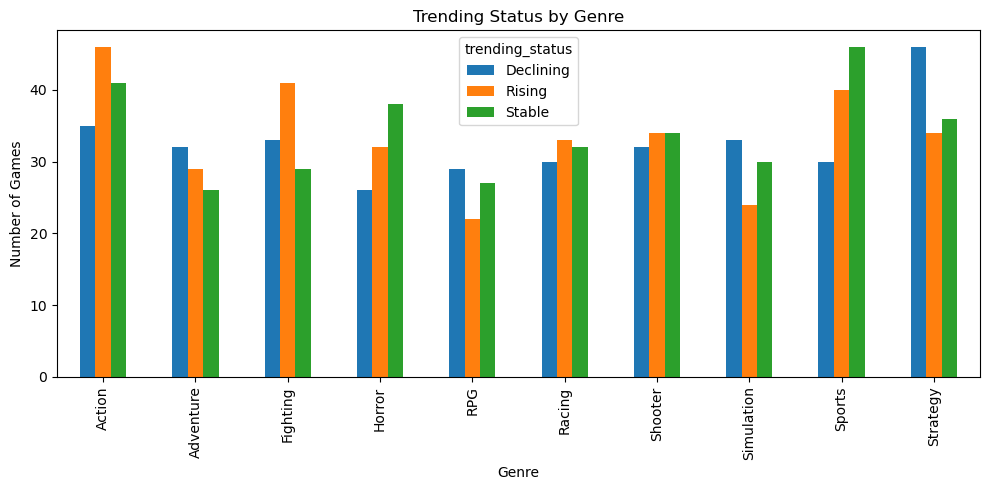

In [16]:
genre_trends.plot(kind="bar", figsize=(10, 5))
plt.title("Trending Status by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Games")
plt.tight_layout()
plt.show()

In [17]:
esports_impact = df.groupby("esports_popularity")[["revenue_millions_", "players_millions"]] \
    .mean()

esports_impact

,revenue_millions_,players_millions
esports_popularity,,
No,2462.085436,104.440974
Yes,2503.372150,102.584655


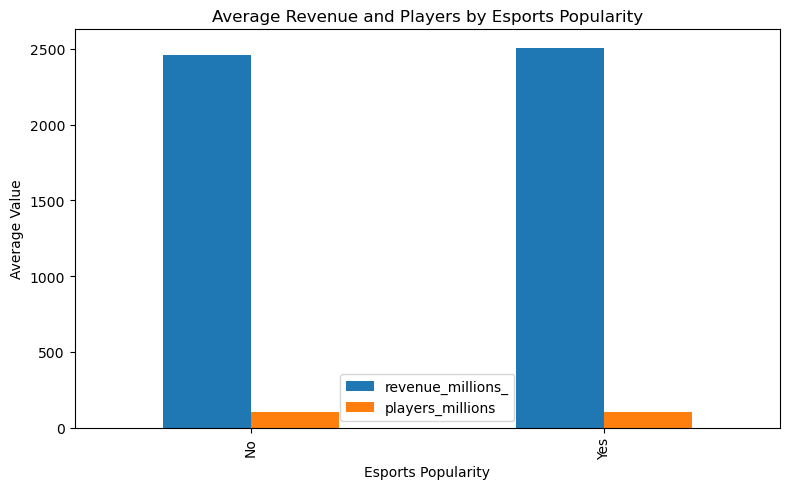

In [18]:
esports_impact.plot(kind="bar", figsize=(8, 5))
plt.title("Average Revenue and Players by Esports Popularity")
plt.xlabel("Esports Popularity")
plt.ylabel("Average Value")
plt.tight_layout()
plt.show()

In [19]:
yearly_trends = df.groupby("release_year")[["revenue_millions_", "players_millions"]] \
    .mean()

yearly_trends.head()

,revenue_millions_,players_millions
release_year,,
2000,2826.195517,93.365862
2001,2624.856818,91.577727
2002,2132.067576,112.415152
2003,2411.775000,104.809737
2004,2696.630769,84.891026


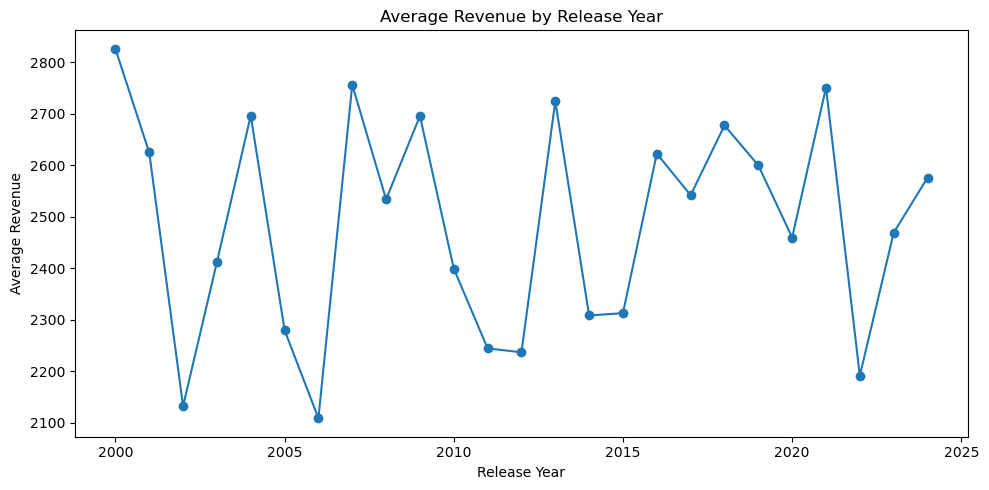

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(yearly_trends.index, yearly_trends["revenue_millions_"], marker="o")
plt.title("Average Revenue by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average Revenue")
plt.tight_layout()
plt.show()

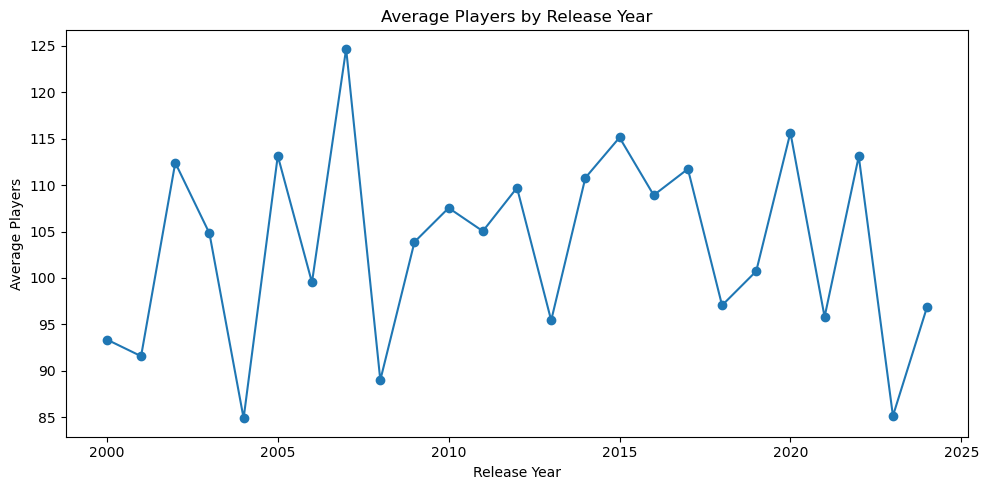

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(yearly_trends.index, yearly_trends["players_millions"], marker="o")
plt.title("Average Players by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average Players")
plt.tight_layout()
plt.show()


In [22]:
developer_perf = df.groupby("developer")[["revenue_millions_", "players_millions", "metacritic_score"]] \
    .mean() \
    .sort_values(by="revenue_millions_", ascending=False)

developer_perf

,revenue_millions_,players_millions,metacritic_score
developer,,,
Capcom,2697.992708,106.205104,76.614583
Sony,2669.302000,107.250083,74.716667
Nintendo,2594.486562,105.441875,74.333333
Activision,2513.671560,103.276147,74.541284
EA,2478.845326,98.082826,74.608696
Bandai Namco,2445.071205,99.356506,75.253012
Rockstar,2422.763645,102.769159,75.168224
Microsoft,2388.449717,100.931321,74.952830
Square Enix,2318.554773,104.352273,76.761364


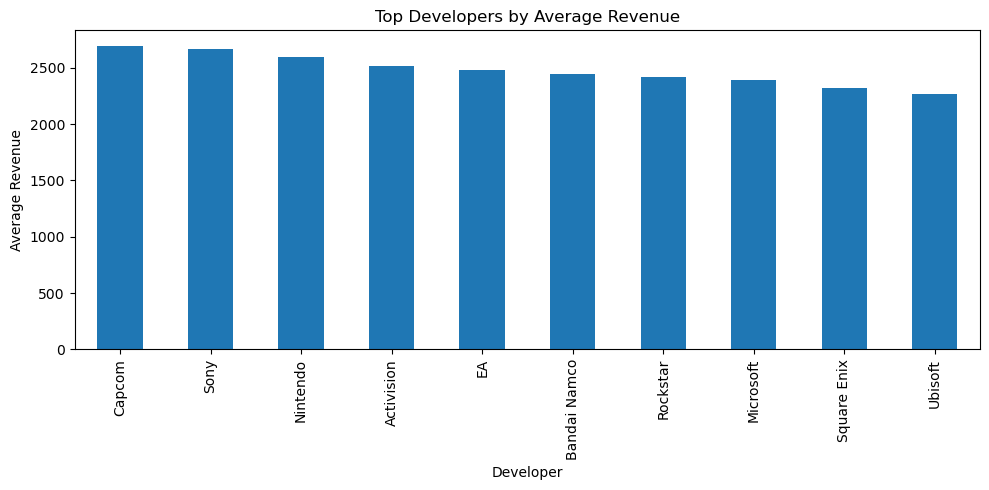

In [23]:
top_developers = developer_perf.head(10)

top_developers["revenue_millions_"].plot(kind="bar", figsize=(10, 5))
plt.title("Top Developers by Average Revenue")
plt.xlabel("Developer")
plt.ylabel("Average Revenue")
plt.tight_layout()
plt.show()

Conclusion

The analysis showed that a few games generate much higher revenue per player than others, suggesting stronger monetization strategies and player engagement. Action, Fighting, and Sports genres appeared to perform better overall, while Strategy games showed more declining trends. Platforms such as Nintendo Switch and Mobile also showed slightly higher average revenue. In addition, major developers like Capcom, Sony, and Nintendo consistently ranked among the top performers.


Overall, the results suggest that gaming success depends on a combination of genre, platform, developer reputation, and monetization efficiency rather than a single factor.